In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("../data/creditcard.csv")

# Statistiques de base
print("=== Valeurs manquantes ===")
print(df.isnull().sum().sum(), "valeurs manquantes")

print("\n=== Distribution de la colonne Amount ===")
print(df["Amount"].describe())

=== Valeurs manquantes ===
0 valeurs manquantes

=== Distribution de la colonne Amount ===
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


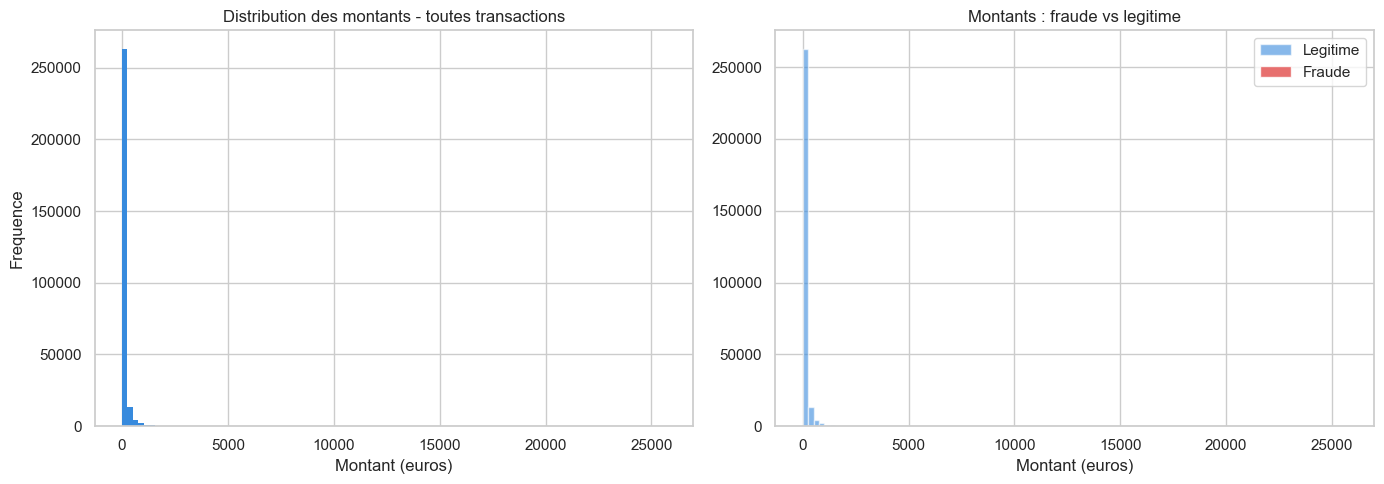

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution globale
axes[0].hist(df["Amount"], bins=100, color="#378ADD", edgecolor="none")
axes[0].set_title("Distribution des montants - toutes transactions")
axes[0].set_xlabel("Montant (euros)")
axes[0].set_ylabel("Frequence")

# Comparaison montants fraude vs legitime
fraud = df[df["Class"] == 1]["Amount"]
legit = df[df["Class"] == 0]["Amount"]

axes[1].hist(legit, bins=100, alpha=0.6, color="#378ADD", label="Legitime")
axes[1].hist(fraud, bins=100, alpha=0.8, color="#E24B4A", label="Fraude")
axes[1].set_title("Montants : fraude vs legitime")
axes[1].set_xlabel("Montant (euros)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/02_distribution_montants.png", dpi=150)
plt.show()

C:\Users\Boly-\AppData\Local\Temp\ipykernel_16792\1958102396.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([legit, fraud], labels=["Legitime", "Fraude"],


=== Statistiques montants par classe ===
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


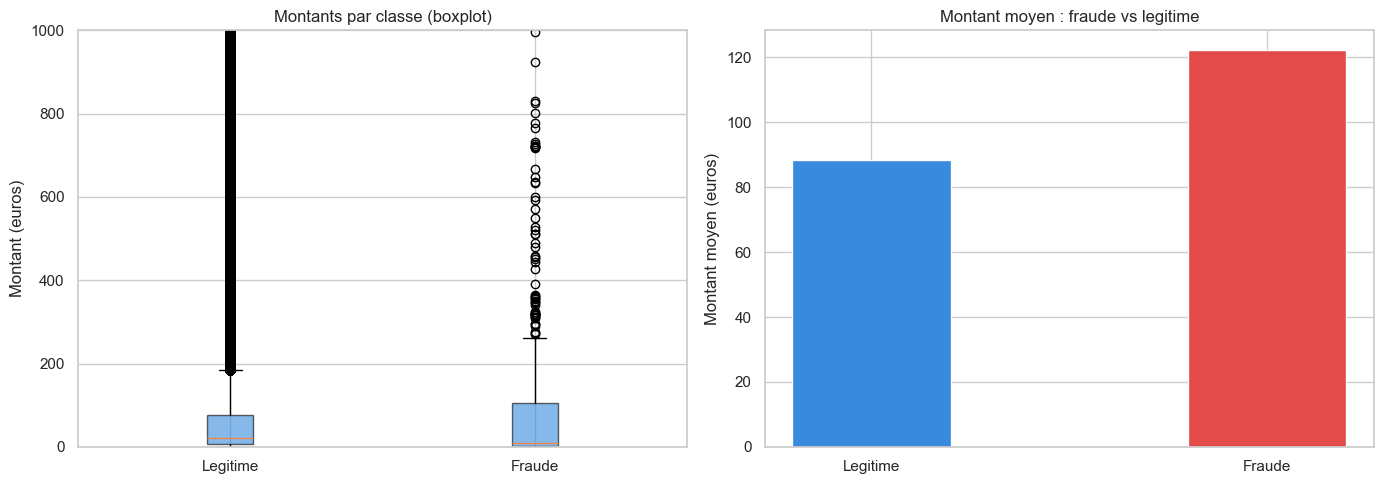

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud = df[df["Class"] == 1]["Amount"]
legit = df[df["Class"] == 0]["Amount"]

# Boxplot comparatif
axes[0].boxplot([legit, fraud], labels=["Legitime", "Fraude"],
                patch_artist=True,
                boxprops=dict(facecolor="#378ADD", alpha=0.6))
axes[0].set_title("Montants par classe (boxplot)")
axes[0].set_ylabel("Montant (euros)")
axes[0].set_ylim(0, 1000)

# Statistiques comparatives
stats = df.groupby("Class")["Amount"].describe()
print("=== Statistiques montants par classe ===")
print(stats)

# Montant moyen fraude vs legitime
axes[1].bar(["Legitime", "Fraude"],
            [legit.mean(), fraud.mean()],
            color=["#378ADD", "#E24B4A"], width=0.4)
axes[1].set_title("Montant moyen : fraude vs legitime")
axes[1].set_ylabel("Montant moyen (euros)")

plt.tight_layout()
plt.savefig("../outputs/03_montants_comparatif.png", dpi=150)
plt.show()